# Figure 4a

In [10]:
from matplotlib.lines import Line2D
from scipy.interpolate import CubicSpline
import config
import utils
import math
import pandas as pd
import numpy as np

start_flow_volume = 0.000785972404073766
feed_interval = 0.1701723516353244
ramp_factor = 0.0739859459733378


initial_volume = start_flow_volume
flow_volume = initial_volume
ramp_rate = ramp_factor

# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate(S)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            flow_volume *= math.exp(ramp_rate)
            substrate_action = flow_volume
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break


X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
S_C_R = S/X
tvec = tvec[:i]


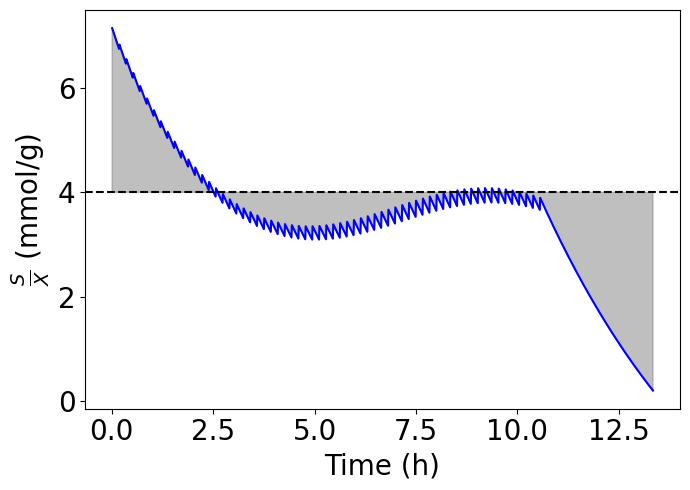

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Example data (replace these with your actual data)
time = tvec 
ratio = S_C_R
optimum_ratio = config.OPT_SUB_CELL_RATIO  # Optimum Ratio

# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"

# Plotting
plt.figure(figsize=(7, 5))

# Plot the ratio
plt.plot(time, ratio*1000, color='blue', label=r"$\frac{S}{X}$ (mmol/g)")

# Plot the optimum ratio as a dashed line
plt.axhline(y=optimum_ratio*1000, color='black', linestyle='--', label=r"$\frac{S}{X}_{optimum}$ (mmol/g)")

plt.fill_between(time, ratio * 1000, optimum_ratio * 1000, where=(ratio > optimum_ratio), color='gray', alpha=0.5)
plt.fill_between(time, ratio * 1000, optimum_ratio * 1000, where=(ratio < optimum_ratio), color='gray', alpha=0.5)

plt.tick_params(axis='both', which='major', labelsize=20)
# Labels and legend
plt.xlabel("Time (h)", fontsize=20)
plt.ylabel(r"$\frac{S}{X}$ (mmol/g)", fontsize=20)
# plt.legend(fontsize=25)

figure_path = os.path.join('figures','figure4','figure4a.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=600)

# Display the plot
plt.tight_layout()
plt.show()


# Figure 4b


----------------- Running RMSE Analysis for ppo_c10+n-10_b100 -----------------
----------------- Model Used <stable_baselines3.ppo.ppo.PPO object at 0x000002006CAE18B0> -----------------
----------------- Running RMSE Analysis for sac_c10+n-10_b100 -----------------
----------------- Model Used <stable_baselines3.sac.sac.SAC object at 0x00000201098751F0> -----------------


C:\Users\Reuel Group\AppData\Local\Temp\ipykernel_27900\1528431960.py:178: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=label_names)


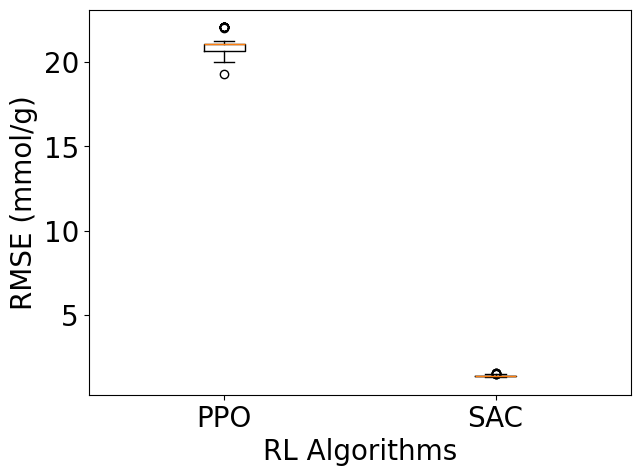

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO,SAC,A2C,TD3, DDPG
import utils
import matplotlib.pyplot as plt

experiments = os.listdir("experiments")
experiment_names = []

for name in experiments:
    if 'sac_c10+n-10_b100' in name or 'ppo_c10+n-10_b100' in name:
        experiment_names.append(name)

figure_data = {}

for experiment_name in experiment_names:
    experiment_folder = os.path.join("experiments",experiment_name)
    best_model_folder = os.path.join(experiment_folder, "model" )
    best_model_path = os.path.join(best_model_folder, "best_model.zip")

    if 'ppo' in experiment_name:
        best_model_path = os.path.join(best_model_folder, f'{experiment_name}.zip')
        loaded_model = PPO.load(best_model_path)
    elif 'sac' in experiment_name:
        loaded_model = SAC.load(best_model_path)
    elif 'a2c' in experiment_name:
        loaded_model = A2C.load(best_model_path)
    elif 'td3' in experiment_name:
        loaded_model = TD3.load(best_model_path)
    elif 'ddpg' in experiment_name:
        loaded_model = DDPG.load(best_model_path)
    
    print(f"----------------- Running RMSE Analysis for {experiment_name} -----------------")
    print(f"----------------- Model Used {loaded_model} -----------------")
   

    figure_data[experiment_name] = []
    num_experiments = 100

    for experiment in range(1, num_experiments+1):
        # Initial conditions
        X0 = config.X0  # CDW g/L 
        S0 = config.S0 # mol/L
        E0 = config.E0 # U/L 

        # Process conditions
        T = config.INIT_TEMPRATURE #'C 
        T_opt = config.OPTIMUM_TEMPERATURE #'C
        A = config.INIT_AGITATION # RPM

        # model parameters
        Ks = config.KS    # mol/L
        Yxs =  config.YXS  # CDW g/mol
        MuE_opt = config.MUE_OPT    # U/CDW g
        mu_max = config.MU_MAX   # /h
        del_t = config.DEL_T # hours ie. 36 seconds
        t_end = config.T_END
        total_sim_steps = int(t_end/del_t)
        tvec = [del_t + i * del_t for i in range(total_sim_steps)]
        ns = len(tvec)
        kl = config.KL # mol/L
        cell_death_timer = config.CELL_DEATH_TIMER
        cell_death_time = config.CELL_DEATH_TIME

        # Substrate addition calculations
        tank_capacity = config.TANK_CAPACITY # L
        substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
        max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
        substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
        media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
        media_transfer_step = int(media_transfer_gap/del_t)
        substrate_concentration = S0
        sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

        # external media tank configurations
        ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
        substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

        # X S E delE delX, muE
        D = np.zeros((ns+1, 6))
        D[0][0] = X0
        D[0][1] = substrate_concentration
        D[0][2] = E0
        for i in range(ns):
            X = D[i][0]
            S = D[i][1]
            E = D[i][2]

            MuX = utils.cell_growth_rate(S)
            # new cells that are generated
            dXdt = utils.cells_produced(X, MuX)

            # SUbstrate consumption
            dSdt = utils.substrate_consumed(dXdt)

            # Find change in cells 
            delX = dXdt * del_t
            # Update cells
            D[i+1][0] = X + delX
            
            # Find change in substrate
            delS = dSdt * del_t

            # # Update substrate
            if substrate_in_tank_liters < max_substrate_limit_liters:
                if i%(media_transfer_step) == 0 and i != 0:
                    if loaded_model.observation_space.shape[0] == 2:
                        model_input = np.array([i, E])
                    elif loaded_model.observation_space.shape[0] == 3:
                        model_input = np.array([i, E, X])
                    action = loaded_model.predict(model_input, deterministic=False)
                    substrate_action = action[0][0]
                    if True:
                        # get substrate concentraion for current timestep
                        substrate_concentration = S
                        sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                        # Add substrate and calculate new concentraion
                        substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                        sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                        substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                        S = substrate_concentration

            # Check if substrate is less than or close to 0
            if S + delS < 0.000001:
                D[i+1][1] = 0
            else:
                D[i+1][1] = S + delS

            # Enzyme determination 
            sub_cell_ratio = (S/X) * 1e6

            weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
            MuE = MuE_opt * weibull

            if dXdt == 0:
                MuE = 0

            # new enzyme from fresh cells
            delE = MuE * X * del_t
            
            # Update enzyme variable
            D[i+1][2] = E + delE

            # terminate if tank capacity is full and cells start dying
            if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
                break
            
        X = D[:,0][0:i]
        S = D[:,1][0:i]
        E = D[:,2][0:i]
        ratios = (S/X)
        rmse = utils.calculate_rmse( ratios, config.OPT_SUB_CELL_RATIO )  
        figure_data[experiment_name].append(rmse)


# Time points
time = list(range(1, 101))  # Time from 1 to 100
data = []
label_names = []

for key, values in figure_data.items():
    data.append(np.array(values)*1e3)
    label_names.append(key.split('_')[0].upper())
# Combine lists into a single list of lists for the box plot

# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"

plt.figure(figsize=(7, 5))
# Create the box plot
plt.boxplot(data, labels=label_names)

# Customize the plot
plt.ylabel('RMSE (mmol/g)', fontsize=20)
plt.xlabel('RL Algorithms', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
figure_path = os.path.join('figures','figure4','figure4b.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=600)


# Show the plot
plt.show()



# Figure 4c


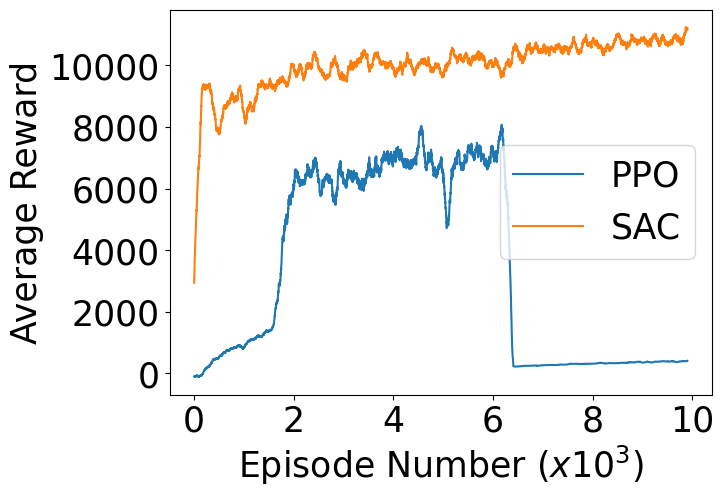

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def moving_average(data, window_size=5):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

experiment_names = ['ppo_c10+n-10_b100', 'sac_c10+n-10_b100']  # Add other experiments if needed

plt.figure(figsize=(7, 5))  # Set figure size

for experiment in experiment_names:
    rewards = []
    experiment_numbers = []
    experiment_folder_path = os.path.join('experiments', experiment)
    training_data_path = os.path.join(experiment_folder_path, 'training_data.csv')

    df = pd.read_csv(training_data_path)
    index_value = df.index[df['timestep'] == 0].tolist()

    for i in range(len(index_value)):
        if i != len(index_value) - 1:
            start_index = index_value[i]
            end_index = index_value[i + 1] - 1

            subset_df = df.loc[start_index:end_index, ['reward', 'experiment_number']]
            reward_sum = subset_df['reward'].sum()
            rewards.append(reward_sum)
            experiment_number = subset_df['experiment_number'].iloc[0]
            experiment_numbers.append(experiment_number/1e3)
    if 'ppo' in experiment:
        display_name = "PPO"
    elif 'sac' in experiment:
        display_name = "SAC"
    # Apply moving average smoothing
    if len(rewards) > 100:  # Ensure enough points for smoothing
        smoothed_rewards = moving_average(rewards, window_size=100)
        smoothed_experiment_numbers = experiment_numbers[:len(smoothed_rewards)]
        plt.plot(smoothed_experiment_numbers, smoothed_rewards, label=display_name)
    else:
        plt.plot(experiment_numbers, rewards, label=experiment)

# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"

plt.xlabel(r"Episode Number $(x10^3)$", fontsize=25)
plt.ylabel("Average Reward", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)  # Add legend for multiple experiments
# Save the figure
figure_path = os.path.join('figures', 'figure4', 'figure4c.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=600)
plt.show()  # Display the plot




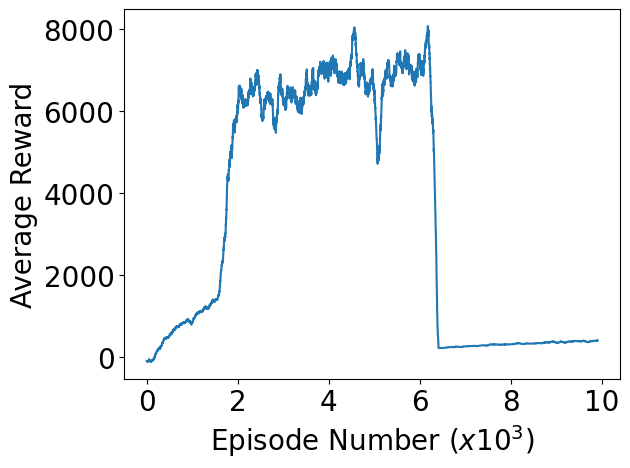

In [12]:
plt.plot(smoothed_experiment_numbers, smoothed_rewards, label=display_name)
# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"

plt.xlabel(r"Episode Number $(x10^3)$", fontsize=20)
plt.ylabel("Average Reward", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# plt.legend(fontsize=20)  # Add legend for multiple experiments
# Save the figure
figure_path = os.path.join('figures', 'figure4', 'figure4c.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=600)
plt.show()  # Display the plot

# Figure4d

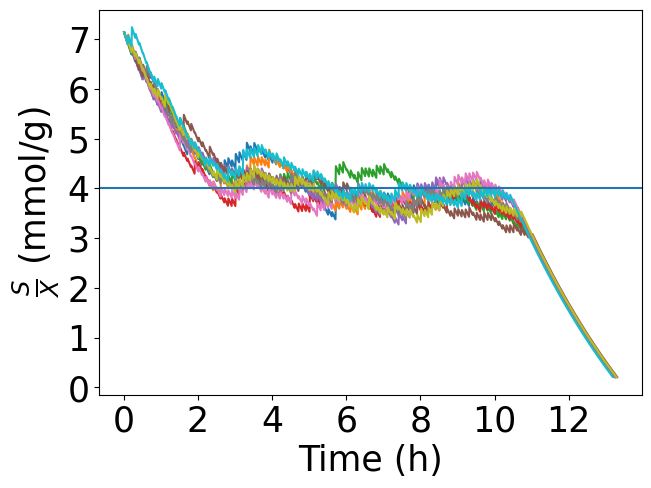

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os
from stable_baselines3 import PPO, SAC
import utils

models_path = "experiments/sac_c10+n-10_b100'/model"
model_name = "SAC"
figures = "testing_figures"

if not os.path.exists(figures):
    os.makedirs(figures)
    
best_model_path = os.path.join(models_path, "best_model.zip" )
last_saved_model_name = os.path.join(models_path, f"{config.EXPERIMENT_NAME}.zip" )

# Initiate the model dynamically based on config.MODEL
if model_name == "PPO":
    loaded_model = PPO.load(best_model_path)
elif model_name == "SAC":
    loaded_model = SAC.load(best_model_path)
else:
    raise ValueError(f"Unknown model name: {model_name}")


rmse_list = []
all_ratios = []
num_experiments = 10

plt.figure(figsize=(7,5))
for experiment in range(1, num_experiments+1):
    # Initial conditions
    X0 = config.X0  # CDW g/L 
    S0 = config.S0 # mol/L
    E0 = config.E0 # U/L 

    # Process conditions
    T = config.INIT_TEMPRATURE #'C 
    T_opt = config.OPTIMUM_TEMPERATURE #'C
    A = config.INIT_AGITATION # RPM

    # model parameters
    Ks = config.KS    # mol/L
    Yxs =  config.YXS  # CDW g/mol
    MuE_opt = config.MUE_OPT    # U/CDW g
    mu_max = config.MU_MAX   # /h
    del_t = config.DEL_T # hours ie. 36 seconds
    t_end = config.T_END
    total_sim_steps = int(t_end/del_t)
    tvec = [del_t + i * del_t for i in range(total_sim_steps)]
    ns = len(tvec)
    kl = config.KL # mol/L
    cell_death_timer = config.CELL_DEATH_TIMER
    cell_death_time = config.CELL_DEATH_TIME

    # Substrate addition calculations
    tank_capacity = config.TANK_CAPACITY # L
    substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
    max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
    substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
    media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
    media_transfer_step = int(media_transfer_gap/del_t)
    substrate_concentration = S0
    sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

    # external media tank configurations
    ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
    substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

    # X S E delE delX, muE
    D = np.zeros((ns+1, 6))
    D[0][0] = X0
    D[0][1] = substrate_concentration
    D[0][2] = E0
    for i in range(ns):
        X = D[i][0]
        S = D[i][1]
        E = D[i][2]

        MuX = utils.cell_growth_rate(S)
        # new cells that are generated
        dXdt = utils.cells_produced(X, MuX)

        # SUbstrate consumption
        dSdt = utils.substrate_consumed(dXdt)

        # Find change in cells 
        delX = dXdt * del_t
        # Update cells
        D[i+1][0] = X + delX
        
        # Find change in substrate
        delS = dSdt * del_t

        # # Update substrate
        if substrate_in_tank_liters < max_substrate_limit_liters:
            if i%(media_transfer_step) == 0 and i != 0:
                model_input = np.array([i, E, X])
                action = loaded_model.predict(model_input, deterministic=False)
                substrate_action = action[0][0]
                if True:
                    # get substrate concentraion for current timestep
                    substrate_concentration = S
                    sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                    # Add substrate and calculate new concentraion
                    substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                    sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                    substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                    S = substrate_concentration

        # Check if substrate is less than or close to 0
        if S + delS < 0.000001:
            D[i+1][1] = 0
        else:
            D[i+1][1] = S + delS

        # Enzyme determination 
        sub_cell_ratio = (S/X) * 1e6

        weibull = utils.get_weibull_y_value(sub_cell_ratio, peak = config.OPT_SUB_CELL_RATIO*1e6)
        MuE = MuE_opt * weibull

        if dXdt == 0:
            MuE = 0

        # new enzyme from fresh cells
        delE = MuE * X * del_t
        
        # Update enzyme variable
        D[i+1][2] = E + delE

        # terminate if tank capacity is full and cells start dying
        if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
            break
        
    X = D[:,0][0:i]
    S = D[:,1][0:i]
    E = D[:,2][0:i]
    ratios = (S/X)
    plt.plot(tvec[:i], ratios*1e3)
    all_ratios.append(ratios)
# Set global font to Times New Roman
plt.rcParams["font.family"] = "sans-serif"

plt.xlabel("Time (h)", fontsize=25)
plt.axhline(y=config.OPT_SUB_CELL_RATIO*1e3)
plt.ylabel(r"$\frac{S}{X}$ (mmol/g)", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
figure_path = os.path.join('figures','figure4','figure4d.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=600)
